# 实验六：形态学图像处理

**实验目的：**
掌握数学形态学的基本操作（腐蚀、膨胀、开运算、闭运算）及其在提取图像边界、骨架和噪声去除中的应用。

**基本概念：**
形态学操作通常针对**二值图像**（只有 0 和 255）。我们用一个叫做**结构元素（Kernel）**的小矩阵在图像上滑动，根据两者的交集/并集情况来改变像素值。


✅ 基础二值图像生成成功！


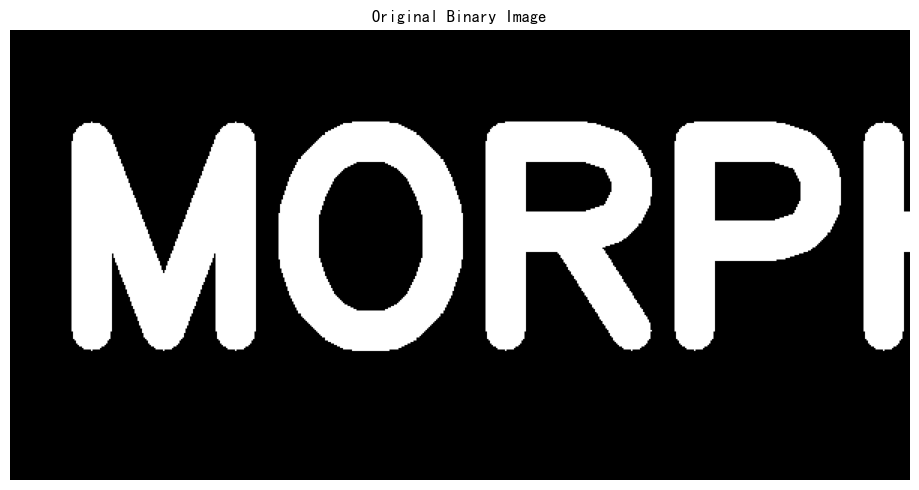

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 为了保证实验效果，我们创建一个包含纯净文字的二值图像
# 创建一个纯黑背景
img = np.zeros((300, 600), dtype=np.uint8)
# 在背景上写上白色粗体文字 "MORPH"
cv2.putText(img, 'MORPH', (30, 200), cv2.FONT_HERSHEY_SIMPLEX, 6, 255, 25)

print(" 基础二值图像生成成功！")
show_images([img], ["Original Binary Image"])


## 1. 腐蚀 (Erosion) 与 膨胀 (Dilation)
* **腐蚀**：让高亮区域（白色）“瘦身”。只要结构元素滑动范围内有一个黑点，中心就变黑。用来断开细弱的连接。
* **膨胀**：让高亮区域（白色）“长胖”。只要结构元素滑动范围内有一个白点，中心就变白。用来弥合细小的裂缝。


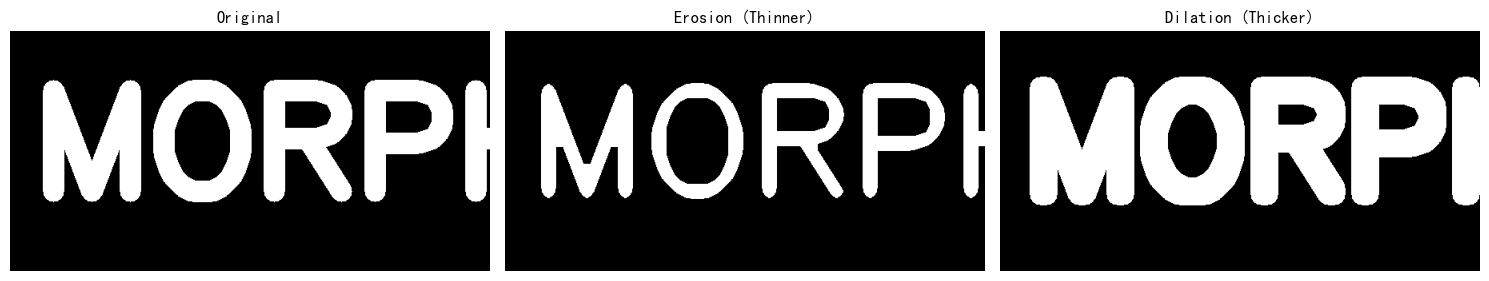

In [2]:
# 定义结构元素 (Kernel) - 这里使用 9x9 的全 1 方阵
kernel = np.ones((9, 9), np.uint8)

# 1. 腐蚀操作 (Erosion)
img_erosion = cv2.erode(img, kernel, iterations=1)

# 2. 膨胀操作 (Dilation)
img_dilation = cv2.dilate(img, kernel, iterations=1)

show_images([img, img_erosion, img_dilation], 
            ["Original", "Erosion (Thinner)", "Dilation (Thicker)"])


## 2. 开运算 (Opening) 与 闭运算 (Closing)
为了展示它们的威力，我们先给原图**人为添加外部的噪点（白点）和内部的孔洞（黑点）**。
* **开运算 = 先腐蚀后膨胀**。奇效：消除外部孤立的小白点，同时保持主体大小不变。
* **闭运算 = 先膨胀后腐蚀**。奇效：填补主体内部的小黑洞，同时保持主体大小不变。


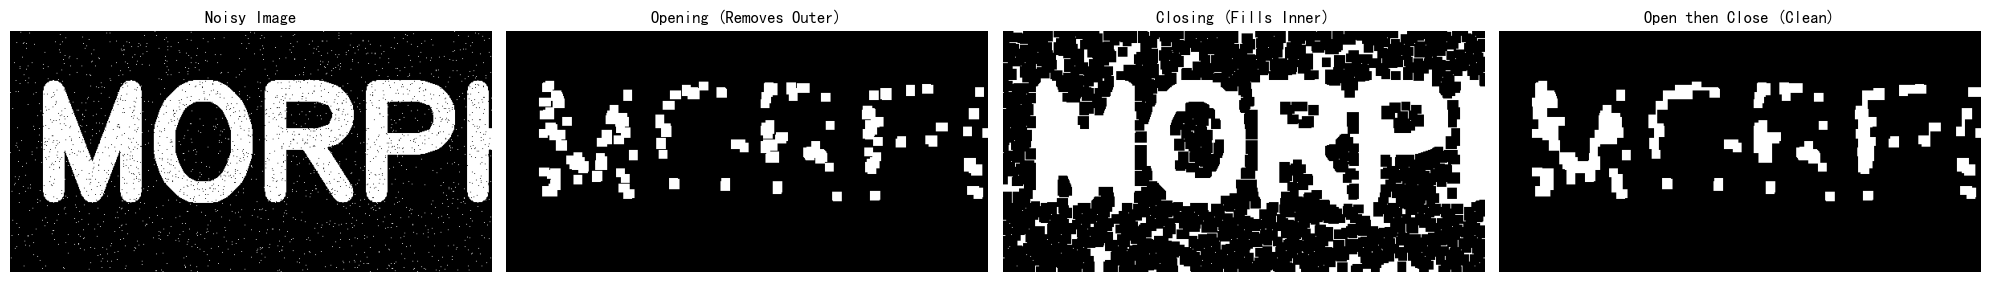

In [3]:
# --- 制造含有噪点和孔洞的污染图像 ---
img_noisy = img.copy()
# 添加外部白噪点 (毛刺)
noise_out = np.random.randint(0, 2, img.shape, dtype=np.uint8) * 255
img_noisy = cv2.bitwise_or(img_noisy, noise_out & (np.random.rand(*img.shape) > 0.98).astype(np.uint8)*255)
# 添加内部黑孔洞
noise_in = np.random.randint(0, 2, img.shape, dtype=np.uint8) * 255
img_noisy = cv2.bitwise_and(img_noisy, cv2.bitwise_not(noise_in & (np.random.rand(*img.shape) > 0.95).astype(np.uint8)*255))

# 定义稍大一点的结构元素，确保能覆盖掉噪点
kernel_oc = np.ones((11, 11), np.uint8)

# 1. 开运算 (消除外部白噪点)
img_opening = cv2.morphologyEx(img_noisy, cv2.MORPH_OPEN, kernel_oc)

# 2. 闭运算 (填补内部黑孔洞)
img_closing = cv2.morphologyEx(img_noisy, cv2.MORPH_CLOSE, kernel_oc)

# 3. 终极净化：先开运算再去闭运算
img_clean = cv2.morphologyEx(img_opening, cv2.MORPH_CLOSE, kernel_oc)

show_images([img_noisy, img_opening, img_closing, img_clean], 
            ["Noisy Image", "Opening (Removes Outer)", "Closing (Fills Inner)", "Open then Close (Clean)"], 
            figsize=(20, 5))


## 3. 利用形态学提取物体边界
提取边界的核心逻辑非常巧妙：**物体边缘 = 原图 - 腐蚀后的图**。
因为腐蚀操作会把物体的边缘“剥去”一层，用原本肥胖的身体减去瘦弱的身体，剩下的就正好是一圈外壳！


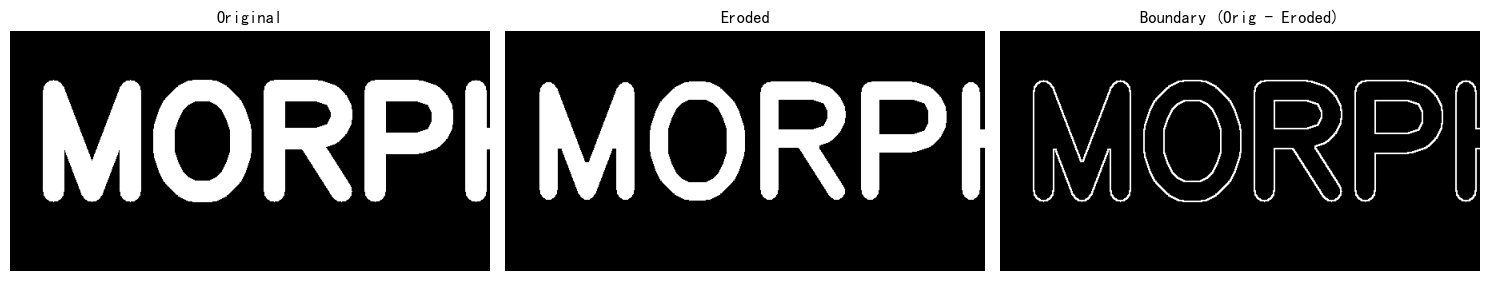

💡 结论：只用几行简单的像素加减法，我们就完美抠出了字体的轮廓！


In [ ]:
# 使用一个小一点的 kernel 来提取较细的边缘
kernel_edge = np.ones((5, 5), np.uint8)

# 对原图进行腐蚀
img_erode_for_edge = cv2.erode(img, kernel_edge, iterations=1)

# 原图减去腐蚀图 (使用 cv2.subtract 防止数值溢出)
img_boundary = cv2.subtract(img, img_erode_for_edge)

show_images([img, img_erode_for_edge, img_boundary], 
            ["Original", "Eroded", "Boundary (Orig - Eroded)"])

# 拓展：OpenCV 直接提供了一种叫做形态学梯度 (Morphological Gradient) 的操作，
# 它的原理是：膨胀图 - 腐蚀图，得到的边界会比上面的方法粗一倍。
img_gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel_edge)

print(" 结论：只用几行简单的像素加减法，我们就完美抠出了字体的轮廓！")
